# Logistic Regression — Fake News Classifier

Binary classification of political statements as true (0) or false (1).

LR establishes the linear baseline. It is fast, and competitive enough with many features/dimentions. Everything after this — Random Forest, LGBM, CatBoost, transformers — is measured against the ceiling this model sets.

**Architecture:**
- Sentence embeddings (`all-MiniLM-L6-v2`, 384-dim) for the statement text
- Porter stemmer ON (compresses vocabulary for TF-IDF-style reasoning; OFF for tree models)
- Scaling ON (`standardize`) for all numeric modules — LR is not scale-invariant
- Text-style features: negation, hedge, absolutist, numeral counts + readability + sentiment
- True-rate features (speaker/subject/party false-claim rates) computed fold-safe inside CV
- Nested CV: 5-fold outer, 3-fold inner `RandomizedSearchCV` over C and penalty (L1 vs L2)
- **Isotonic calibration** on the final model — improves probability estimates for threshold tuning
- Threshold tuning on OOF probabilities, optimising macro F1

**Metric:** Macro F1 (primary) — forces the model to predict both classes, not just the majority.

## Imports and Project Setup

In [1]:
from datetime import datetime
from pathlib import Path
import sys
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'train.csv').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')

project_root = find_project_root(Path.cwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocessing.one_step import OneStepOptions, preprocess_one_step

print(f'Project root: {project_root}')

_script_start = time()
def _now() -> str:
    return datetime.now().strftime('%H:%M:%S')

c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp


## Data Loading

8,950 labeled samples. Class distribution: ~35% true (0), ~65% false (1).  
Class imbalance is handled via `class_weight = {0: 1.42, 1: 0.77}` — the balanced formula `n / (2 * n_class_i)`.  
No resampling is used: class weighting avoids information loss and keeps the validation probabilities correctly scaled.

In [2]:
df = pd.read_csv(project_root / 'data' / 'train.csv')
print(f'Shape: {df.shape}')
print(f"\nLabel distribution:\n{df['label'].value_counts(normalize=True).round(4)}")
df.head()

Shape: (8950, 8)

Label distribution:
label
1    0.6475
0    0.3525
Name: proportion, dtype: float64


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation
0,81f884c64a7,1,China is in the South China Sea and (building)...,"china,foreign-policy,military",donald-trump,President-Elect,New York,republican
1,30c2723a188,0,With the resources it takes to execute just ov...,health-care,chris-dodd,U.S. senator,Connecticut,democrat
2,6936b216e5d,0,The (Wisconsin) governor has proposed tax give...,"corporations,pundits,taxes,abc-news-week",donna-brazile,Political commentator,"Washington, D.C.",democrat
3,b5cd9195738,1,Says her representation of an ex-boyfriend who...,"candidates-biography,children,ethics,families,...",rebecca-bradley,NaN,NaN,none
4,84f8dac7737,0,At protests in Wisconsin against proposed coll...,"health-care,labor,state-budget",republican-party-wisconsin,NaN,Wisconsin,republican


## Preprocessing Configuration

I actually ran many, (all) configurations (in a loop/grid style) of preprocessing on LR, to know which ones were giving me better results. I ended up with current configuration of flags. But then I selected other preprocessing better suited for Tree models

**Key decisions for LR (differs from tree models):**

| Setting | LR | Trees | Reason |
|---|---|---|---|
| Scaling | `standardize` | `none` | LR gradient descent is poorly conditioned across mixed scales |
| Stemmer | `porter` | `none` | Compresses vocabulary; trees gain nothing and may lose distinctions |
| NER features | OFF | ON | Slow; marginal for LR given embedding input |
| Interaction keys | OFF | ON | LR can only learn main effects; trees compute interactions via splits |
| Sentence embeddings | 384-dim | 384-dim | Same model; embeddings need natural language (no stopword removal) |

In [3]:
# --- Label & ID ---
label_option      = 'skip'
label_source_col  = 'label'
id_option         = 'drop'

# --- Subject ---
subject_source_col             = 'subject'
subject_keep_original          = False
subject_clean_text             = True
subject_normalize_separators   = True
subject_split_topics           = True
subject_primary_strategy       = 'most_frequent'
subject_rare_threshold         = 10
subject_rare_label             = 'other'
subject_max_topics_for_primary = None
subject_multi_topic_label      = 'multi-topic'
subject_add_length_features    = False
subject_add_topic_list         = False
subject_add_topic_count        = True
subject_add_multiple_topics_flag = False
subject_add_primary            = True
subject_add_grouped_primary    = True
subject_group_rare             = True
subject_add_subject_frequency  = False
subject_add_subject_is_rare    = True
subject_add_subject_primary_true_rate = False  # computed fold-safe in CV loop
subject_label_col              = None
subject_scale                  = 'standardize'  # ON: LR needs scaled inputs
subject_verbose                = False

In [4]:
# --- Statement ---
statement_source_col            = 'statement'
statement_original_output_col   = 'statement_original'
statement_output_col            = 'statement_clean'
statement_keep_original         = False
statement_lower                 = True
statement_remove_html           = True
statement_remove_urls           = True
statement_replace_numbers       = False
statement_number_token          = '<NUM>'
statement_stopword_removal      = False   # OFF: embeddings need natural language
statement_keep_negations        = True
statement_remove_punctuation    = False
statement_stemmer               = 'porter'  # ON for LR: compresses vocabulary
statement_lemmatizer            = 'none'
statement_repair_polluted_statements = True
statement_add_rare_token_features = False
statement_rare_token_threshold  = 1
statement_token_freqs           = None
statement_add_spelling_errors   = False
statement_add_lexical_features  = True    # char_len, word_count, upper_ratio, etc.
statement_add_pollution_features = False
statement_add_ner_features      = False   # OFF: slow, marginal for LR
statement_ner_model             = 'en_core_web_sm'
statement_vectorizer_type       = 'embeddings'
statement_vectorizer_max_features = 5000
statement_vectorizer_min_df     = 2
statement_vectorizer_max_df     = 0.9
statement_embedding_model       = 'all-MiniLM-L6-v2'  # 384-dim
statement_fitted_vectorizer     = None
statement_scale                 = 'standardize'  # ON: needed for LR
statement_verbose               = False

In [5]:
# --- Speaker ---
speaker_source_col            = 'speaker'
speaker_keep_original         = False
speaker_clean_text            = True
speaker_normalize_separators  = True
speaker_group_rare            = True
speaker_rare_threshold        = 5
speaker_rare_label            = 'other'
speaker_add_length_features   = False
speaker_add_frequency         = True
speaker_add_is_rare           = True
speaker_add_grouped_speaker   = True
speaker_add_title_flag        = True
speaker_add_comma_flag        = True
speaker_add_period_flag       = False
speaker_add_token_count       = False
speaker_add_speaker_primary_true_rate = False
speaker_label_col             = None
speaker_scale                 = 'standardize'
speaker_verbose               = False

# --- Speaker job ---
speaker_job_source_col           = 'speaker_job'
speaker_job_keep_original        = False
speaker_job_clean_text           = True
speaker_job_normalize_separators = True
speaker_job_group_rare           = False
speaker_job_rare_threshold       = 5
speaker_job_rare_label           = 'other'
speaker_job_add_length_features  = True
speaker_job_add_frequency        = False
speaker_job_add_is_rare          = False
speaker_job_add_grouped_job      = False
speaker_job_add_title_flag       = True
speaker_job_add_comma_flag       = True
speaker_job_add_slash_flag       = False
speaker_job_add_ampersand_flag   = False
speaker_job_add_token_count      = False
speaker_job_add_job_primary_true_rate = False
speaker_job_job_label_col        = None
speaker_job_scale                = 'none'
speaker_job_verbose              = False

# --- Party affiliation ---
party_affiliation_source_col       = 'party_affiliation'
party_affiliation_keep_original    = False
party_affiliation_clean_text       = True
party_affiliation_group_rare       = True
party_affiliation_rare_threshold   = 5
party_affiliation_rare_label       = 'other'
party_affiliation_add_length_features = True
party_affiliation_add_frequency    = True
party_affiliation_add_is_rare      = True
party_affiliation_add_grouped_party = True
party_affiliation_add_slash_flag   = True
party_affiliation_add_ampersand_flag = True
party_affiliation_add_comma_flag   = False
party_affiliation_add_parentheses_flag = True
party_affiliation_add_token_count  = True
party_affiliation_add_is_major_party = True
party_affiliation_add_is_institutional = True
party_affiliation_add_party_primary_true_rate = False
party_affiliation_party_label_col  = None
party_affiliation_scale            = 'standardize'
party_affiliation_verbose          = False

# --- State info ---
state_source_col       = 'state_info'
state_drop             = False
state_keep_original    = False
state_clean_text       = True
state_normalize_state  = True
state_group_rare       = True
state_rare_threshold   = 5
state_rare_label       = 'other'
state_add_is_us_state  = True
state_add_frequency    = False
state_add_is_rare      = False
state_add_grouped_state = True
state_add_length_features = False
state_add_token_count  = True
state_add_has_us_words = False
state_add_us_region    = True
state_scale            = 'none'
state_verbose          = False

In [6]:
# --- Feature Engineering ---
# LR differences vs trees:
#   - All interaction keys OFF: LR can't learn "speaker X on topic Y" without an explicit
#     interaction term — the key would have ~1000+ unique values and LR collapses to
#     arbitrary ordinal integers, which is meaningless for a linear boundary.
#   - True-rate aggregates computed fold-safe in CV loop (same as trees).
#   - Text-style features ON: these are low-cardinality numeric signals that LR can use directly.

fe_statement_col          = 'statement_clean'
fe_statement_original_col = 'statement_original'
fe_speaker_col            = 'speaker_clean'
fe_subject_col            = 'subject_clean'
fe_party_col              = 'party_affiliation_clean'
fe_speaker_job_col        = 'speaker_job_clean'
fe_state_col              = 'state_info_clean'
fe_label_col              = None

# Interaction keys — OFF for LR (high cardinality, meaningless as ordinal integers)
fe_add_speaker_subject            = False
fe_add_speaker_party              = False
fe_add_subject_party              = False
fe_add_speaker_job_subject        = False
fe_add_state_party                = False
fe_add_speaker_statement_len_bucket = False
fe_statement_len_bins             = (50, 150)

# True-rate aggregates — OFF here, computed fold-safe in CV loop
fe_add_speaker_true_rate          = False
fe_add_subject_true_rate          = False
fe_add_party_true_rate            = False

# Non-leaking aggregates — OFF for LR (few extra gain vs compute cost)
fe_add_speaker_avg_statement_len  = False
fe_add_subject_avg_statement_len  = False
fe_add_speaker_avg_punctuation    = False
fe_add_speaker_avg_number_ratio   = False

# Text-style features — ON: deception-detection signals, low cardinality, LR-compatible
fe_add_negation_count    = True
fe_add_hedge_count       = True
fe_add_absolutist_count  = True
fe_add_numeral_count     = True
fe_add_proper_noun_count = False  # requires statement_original (not kept)
fe_add_readability       = True
fe_add_sentiment         = True

fe_scale    = 'standardize'  # ON: LR needs scaled counts
fe_verbose  = False

In [7]:
options = OneStepOptions(
    label_option=label_option, label_source_col=label_source_col, id_option=id_option,
    subject_source_col=subject_source_col, subject_keep_original=subject_keep_original,
    subject_clean_text=subject_clean_text, subject_normalize_separators=subject_normalize_separators,
    subject_split_topics=subject_split_topics, subject_primary_strategy=subject_primary_strategy,
    subject_max_topics_for_primary=subject_max_topics_for_primary,
    subject_multi_topic_label=subject_multi_topic_label,
    subject_add_length_features=subject_add_length_features,
    subject_add_topic_list=subject_add_topic_list, subject_add_topic_count=subject_add_topic_count,
    subject_add_multiple_topics_flag=subject_add_multiple_topics_flag,
    subject_add_primary=subject_add_primary, subject_add_grouped_primary=subject_add_grouped_primary,
    subject_group_rare=subject_group_rare, subject_rare_threshold=subject_rare_threshold,
    subject_rare_label=subject_rare_label, subject_add_subject_frequency=subject_add_subject_frequency,
    subject_add_subject_is_rare=subject_add_subject_is_rare,
    subject_add_subject_primary_true_rate=subject_add_subject_primary_true_rate,
    subject_label_col=subject_label_col, subject_scale=subject_scale, subject_verbose=subject_verbose,
    statement_source_col=statement_source_col, statement_original_output_col=statement_original_output_col,
    statement_output_col=statement_output_col, statement_keep_original=statement_keep_original,
    statement_lower=statement_lower, statement_remove_html=statement_remove_html,
    statement_remove_urls=statement_remove_urls, statement_replace_numbers=statement_replace_numbers,
    statement_number_token=statement_number_token, statement_stopword_removal=statement_stopword_removal,
    statement_keep_negations=statement_keep_negations, statement_stemmer=statement_stemmer,
    statement_lemmatizer=statement_lemmatizer, statement_remove_punctuation=statement_remove_punctuation,
    statement_repair_polluted_statements=statement_repair_polluted_statements,
    statement_add_rare_token_features=statement_add_rare_token_features,
    statement_rare_token_threshold=statement_rare_token_threshold,
    statement_token_freqs=statement_token_freqs, statement_add_spelling_errors=statement_add_spelling_errors,
    statement_add_lexical_features=statement_add_lexical_features,
    statement_add_pollution_features=statement_add_pollution_features,
    statement_verbose=statement_verbose, statement_add_ner_features=statement_add_ner_features,
    statement_ner_model=statement_ner_model, statement_vectorizer_type=statement_vectorizer_type,
    statement_vectorizer_max_features=statement_vectorizer_max_features,
    statement_vectorizer_min_df=statement_vectorizer_min_df,
    statement_vectorizer_max_df=statement_vectorizer_max_df,
    statement_embedding_model=statement_embedding_model,
    statement_fitted_vectorizer=statement_fitted_vectorizer,
    statement_scale=statement_scale,
    speaker_source_col=speaker_source_col, speaker_keep_original=speaker_keep_original,
    speaker_clean_text=speaker_clean_text, speaker_normalize_separators=speaker_normalize_separators,
    speaker_group_rare=speaker_group_rare, speaker_rare_threshold=speaker_rare_threshold,
    speaker_rare_label=speaker_rare_label, speaker_add_length_features=speaker_add_length_features,
    speaker_add_frequency=speaker_add_frequency, speaker_add_is_rare=speaker_add_is_rare,
    speaker_add_grouped_speaker=speaker_add_grouped_speaker, speaker_add_title_flag=speaker_add_title_flag,
    speaker_add_comma_flag=speaker_add_comma_flag, speaker_add_period_flag=speaker_add_period_flag,
    speaker_add_token_count=speaker_add_token_count,
    speaker_add_speaker_primary_true_rate=speaker_add_speaker_primary_true_rate,
    speaker_label_col=speaker_label_col, speaker_scale=speaker_scale, speaker_verbose=speaker_verbose,
    speaker_job_source_col=speaker_job_source_col, speaker_job_keep_original=speaker_job_keep_original,
    speaker_job_clean_text=speaker_job_clean_text,
    speaker_job_normalize_separators=speaker_job_normalize_separators,
    speaker_job_group_rare=speaker_job_group_rare, speaker_job_rare_threshold=speaker_job_rare_threshold,
    speaker_job_rare_label=speaker_job_rare_label,
    speaker_job_add_length_features=speaker_job_add_length_features,
    speaker_job_add_frequency=speaker_job_add_frequency, speaker_job_add_is_rare=speaker_job_add_is_rare,
    speaker_job_add_grouped_job=speaker_job_add_grouped_job,
    speaker_job_add_title_flag=speaker_job_add_title_flag,
    speaker_job_add_comma_flag=speaker_job_add_comma_flag,
    speaker_job_add_slash_flag=speaker_job_add_slash_flag,
    speaker_job_add_ampersand_flag=speaker_job_add_ampersand_flag,
    speaker_job_add_token_count=speaker_job_add_token_count,
    speaker_job_add_job_primary_true_rate=speaker_job_add_job_primary_true_rate,
    speaker_job_job_label_col=speaker_job_job_label_col,
    speaker_job_scale=speaker_job_scale, speaker_job_verbose=speaker_job_verbose,
    party_affiliation_source_col=party_affiliation_source_col,
    party_affiliation_keep_original=party_affiliation_keep_original,
    party_affiliation_clean_text=party_affiliation_clean_text,
    party_affiliation_group_rare=party_affiliation_group_rare,
    party_affiliation_rare_threshold=party_affiliation_rare_threshold,
    party_affiliation_rare_label=party_affiliation_rare_label,
    party_affiliation_add_length_features=party_affiliation_add_length_features,
    party_affiliation_add_frequency=party_affiliation_add_frequency,
    party_affiliation_add_is_rare=party_affiliation_add_is_rare,
    party_affiliation_add_grouped_party=party_affiliation_add_grouped_party,
    party_affiliation_add_slash_flag=party_affiliation_add_slash_flag,
    party_affiliation_add_ampersand_flag=party_affiliation_add_ampersand_flag,
    party_affiliation_add_comma_flag=party_affiliation_add_comma_flag,
    party_affiliation_add_parentheses_flag=party_affiliation_add_parentheses_flag,
    party_affiliation_add_token_count=party_affiliation_add_token_count,
    party_affiliation_add_is_major_party=party_affiliation_add_is_major_party,
    party_affiliation_add_is_institutional=party_affiliation_add_is_institutional,
    party_affiliation_add_party_primary_true_rate=party_affiliation_add_party_primary_true_rate,
    party_affiliation_party_label_col=party_affiliation_party_label_col,
    party_affiliation_scale=party_affiliation_scale, party_affiliation_verbose=party_affiliation_verbose,
    state_source_col=state_source_col, state_drop=state_drop, state_keep_original=state_keep_original,
    state_clean_text=state_clean_text, state_normalize_state=state_normalize_state,
    state_group_rare=state_group_rare, state_rare_threshold=state_rare_threshold,
    state_rare_label=state_rare_label, state_add_is_us_state=state_add_is_us_state,
    state_add_frequency=state_add_frequency, state_add_is_rare=state_add_is_rare,
    state_add_grouped_state=state_add_grouped_state, state_add_length_features=state_add_length_features,
    state_add_token_count=state_add_token_count, state_add_has_us_words=state_add_has_us_words,
    state_add_us_region=state_add_us_region, state_scale=state_scale, state_verbose=state_verbose,
    fe_statement_col=fe_statement_col, fe_statement_original_col=fe_statement_original_col,
    fe_speaker_col=fe_speaker_col, fe_subject_col=fe_subject_col, fe_party_col=fe_party_col,
    fe_speaker_job_col=fe_speaker_job_col, fe_state_col=fe_state_col, fe_label_col=fe_label_col,
    fe_add_speaker_subject=fe_add_speaker_subject, fe_add_speaker_party=fe_add_speaker_party,
    fe_add_subject_party=fe_add_subject_party, fe_add_speaker_job_subject=fe_add_speaker_job_subject,
    fe_add_state_party=fe_add_state_party,
    fe_add_speaker_statement_len_bucket=fe_add_speaker_statement_len_bucket,
    fe_statement_len_bins=fe_statement_len_bins,
    fe_add_speaker_true_rate=fe_add_speaker_true_rate, fe_add_subject_true_rate=fe_add_subject_true_rate,
    fe_add_party_true_rate=fe_add_party_true_rate,
    fe_add_speaker_avg_statement_len=fe_add_speaker_avg_statement_len,
    fe_add_subject_avg_statement_len=fe_add_subject_avg_statement_len,
    fe_add_speaker_avg_punctuation=fe_add_speaker_avg_punctuation,
    fe_add_speaker_avg_number_ratio=fe_add_speaker_avg_number_ratio,
    fe_add_negation_count=fe_add_negation_count, fe_add_hedge_count=fe_add_hedge_count,
    fe_add_absolutist_count=fe_add_absolutist_count, fe_add_numeral_count=fe_add_numeral_count,
    fe_add_proper_noun_count=fe_add_proper_noun_count, fe_add_readability=fe_add_readability,
    fe_add_sentiment=fe_add_sentiment, fe_scale=fe_scale, fe_verbose=fe_verbose,
)

## Run Preprocessing

The slowest step (~5–8 min) due to sentence embedding encoding. Output is a numeric-only table — LR drops all remaining string columns.

In [8]:
print(f'[{_now()}] Running preprocessing...')
_t0 = time()
df_processed = preprocess_one_step(df, options=options)
print(f'Done in {time()-_t0:.1f}s  |  Rows: {len(df_processed):,}  |  Columns: {df_processed.shape[1]}')

[20:11:02] Running preprocessing...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10310.33it/s]


Done in 10.1s  |  Rows: 8,950  |  Columns: 434


## Feature Matrix

LR uses only numeric columns — all remaining string columns (grouped categories, regions) are dropped. This is different from trees, which encode them via `OrdinalEncoder`. The embeddings (`vec_*`) dominate the feature count.

In [9]:
X = df_processed.drop(columns=['label']).select_dtypes(exclude='object')
y = df_processed['label']

emb_cols   = [c for c in X.columns if c.startswith('vec_')]
other_cols = [c for c in X.columns if not c.startswith('vec_')]

print(f'Embedding dims   : {len(emb_cols)}')
print(f'Other numeric    : {len(other_cols)}  →  {other_cols}')
print(f'Total features   : {X.shape[1]}')
print(f'\nTarget distribution:\n{y.value_counts(normalize=True).round(4)}')

Embedding dims   : 0
Other numeric    : 420  →  ['subject_topic_count', 'subject_is_rare', 'statement_original_char_len', 'statement_original_word_count', 'statement_upper_ratio', 'statement_exclamation_count', 'statement_question_count', 'statement_clean_digit_ratio', 'statement_original_vec_0', 'statement_original_vec_1', 'statement_original_vec_2', 'statement_original_vec_3', 'statement_original_vec_4', 'statement_original_vec_5', 'statement_original_vec_6', 'statement_original_vec_7', 'statement_original_vec_8', 'statement_original_vec_9', 'statement_original_vec_10', 'statement_original_vec_11', 'statement_original_vec_12', 'statement_original_vec_13', 'statement_original_vec_14', 'statement_original_vec_15', 'statement_original_vec_16', 'statement_original_vec_17', 'statement_original_vec_18', 'statement_original_vec_19', 'statement_original_vec_20', 'statement_original_vec_21', 'statement_original_vec_22', 'statement_original_vec_23', 'statement_original_vec_24', 'statement_orig

## Train / Holdout Split

20% stratified holdout, `random_state=42` — identical across all scripts so the holdout is always the same 1,790 rows.

In [10]:
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Train/val : {X_trainval.shape[0]:,}  |  Holdout : {X_holdout.shape[0]:,}  |  CV folds : {skf.get_n_splits()}')

Train/val : 7,160  |  Holdout : 1,790  |  CV folds : 5


## Model Configuration

**HP - HyperParameters search space:**
- `C`: log-uniform distribution over `[1e-3, 10]` — log-uniform ensures equal probability of small and large C values. Small C = stronger regularisation, large C = closer to unregularised.
- `penalty`: L1 or L2. L1 produces sparse coefficients (most features zero). L2 distributes weight more evenly. The best choice depends on how many features are actually informative.

**Aggregation after nested CV:**
- C: **geometric mean** of fold-best values — appropriate because C is on a log scale.
- penalty: **mode** across folds.

**Isotonic calibration on the final model:**  
LR's `predict_proba` outputs raw sigmoid probabilities. When the training set is imbalanced and class weights are applied, these probabilities are shifted. Isotonic calibration (`CalibratedClassifierCV(method='isotonic', cv=5)`) fits a monotonic function that maps the raw probas to better-calibrated probabilities — useful because our threshold tuning relies on the probas being meaningful.

In [11]:
CLASS_WEIGHT      = {0: 1.42, 1: 0.77}
C_VALUE           = 1.0       # updated by HP search
PENALTY           = 'l2'      # updated by HP search
MAX_ITER          = 1000

balance_strategy  = 'class_weight'  # 'none' | 'class_weight' | 'oversample_reject'

enable_hp_search  = True
N_ITER_SEARCH     = 20
C_DIST            = loguniform(1e-3, 10)

THRESHOLD              = 0.5
enable_threshold_tuning = True
overwrite_threshold     = True
THRESHOLD_METRIC        = 'macro_f1'

enable_true_rate_features = True
true_rate_fallback        = 0.5

_lr_class_weight = CLASS_WEIGHT if balance_strategy == 'class_weight' else None


def rebalance_training_data(X_train, y_train, strategy, random_state=42):
    if strategy in ('none', 'class_weight'):
        return X_train, y_train
    frame = X_train.copy()
    frame['_label'] = y_train.values
    minority = frame[frame['_label'] == 0]
    majority = frame[frame['_label'] == 1]
    if strategy == 'oversample_reject':
        minority = minority.sample(n=len(majority), replace=True, random_state=random_state)
    else:
        raise ValueError(f'Unknown balance_strategy: {strategy!r}')
    balanced = pd.concat([minority, majority]).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns=['_label']), balanced['_label']


print(f'Class weight    : {CLASS_WEIGHT}')
print(f'HP search       : {enable_hp_search}  ({N_ITER_SEARCH} iterations per fold)')
print(f'C distribution  : loguniform(1e-3, 10)')
print(f'Threshold metric: {THRESHOLD_METRIC}')

Class weight    : {0: 1.42, 1: 0.77}
HP search       : True  (20 iterations per fold)
C distribution  : loguniform(1e-3, 10)
Threshold metric: macro_f1


## True-Rate Feature Setup

Speaker, subject, and party false-claim rates are the strongest individual signals on the dataset. They must be computed fold-safe: the mean label per group is computed only on the fold's training split, then mapped to the validation split. Computing on the full dataset would leak label information — inflating CV scores but collapsing on holdout.

Placeholder `0.5` is written now; real values overwrite it inside the CV loop.

In [12]:
_tr_group_cols: dict = {}
if enable_true_rate_features:
    _candidates = {
        'fe_speaker_true_rate': ['speaker_grouped', 'speaker_clean'],
        'fe_subject_true_rate': ['subject_grouped', 'subject_primary', 'subject_clean'],
        'fe_party_true_rate':   ['party_affiliation_grouped', 'party_affiliation_clean'],
    }
    for _feat, _src_cols in _candidates.items():
        for _col in _src_cols:
            if _col in df_processed.columns:
                _tr_group_cols[_feat] = _col
                break

    X_trainval = X_trainval.copy()
    X_holdout  = X_holdout.copy()
    for _feat in _tr_group_cols:
        X_trainval[_feat] = true_rate_fallback
        X_holdout[_feat]  = true_rate_fallback

    _grp_trainval = pd.DataFrame(
        {col: df_processed[col].loc[X_trainval.index].values for col in _tr_group_cols.values()}
    )
    _grp_trainval['_label'] = y_trainval.values

    _grp_holdout = pd.DataFrame(
        {col: df_processed[col].loc[X_holdout.index].values for col in _tr_group_cols.values()}
    )

    print(f'True-rate features : {list(_tr_group_cols.keys())}')
    print(f'Source columns     : {list(_tr_group_cols.values())}')

True-rate features : ['fe_speaker_true_rate', 'fe_subject_true_rate', 'fe_party_true_rate']
Source columns     : ['speaker_grouped', 'subject_primary', 'party_affiliation_grouped']


## Cross-Validation

**Nested CV:**
- **Outer loop (5 folds):** collects OOF probabilities for threshold tuning.
- **Inner loop (3-fold `RandomizedSearchCV`, 20 trials):** finds best C and penalty per fold. `refit=False` because we extract `best_params_` and refit manually — this avoids the inner model being used for OOF prediction.

True-rate features are recomputed on each fold's training split, then mapped to the validation split.

In [13]:
print(f'[{_now()}] Starting cross-validation...')
_cv_start = time()
cv_fold_metrics = []
oof_proba = np.zeros(len(X_trainval))
oof_true  = np.zeros(len(X_trainval), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    _fold_t = time()

    X_fold_train_raw = X_trainval.iloc[train_idx].copy()
    X_fold_val_raw   = X_trainval.iloc[val_idx].copy()

    # Fold-safe true-rate features
    if enable_true_rate_features and _tr_group_cols:
        _grp_tr = _grp_trainval.iloc[train_idx]
        _grp_vl = _grp_trainval.iloc[val_idx]
        for _feat, _src_col in _tr_group_cols.items():
            _rate_map = _grp_tr.groupby(_src_col)['_label'].mean()
            X_fold_train_raw[_feat] = _grp_tr[_src_col].map(_rate_map).fillna(true_rate_fallback).values
            X_fold_val_raw[_feat]   = _grp_vl[_src_col].map(_rate_map).fillna(true_rate_fallback).values

    fold_C, fold_penalty = C_VALUE, PENALTY
    if enable_hp_search:
        _inner = RandomizedSearchCV(
            estimator=LogisticRegression(
                solver='liblinear', class_weight=_lr_class_weight,
                max_iter=MAX_ITER, random_state=42,
            ),
            param_distributions={'C': C_DIST, 'penalty': ['l1', 'l2']},
            n_iter=N_ITER_SEARCH, scoring='f1_macro',
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            n_jobs=-1, refit=False, random_state=42,
        )
        _inner.fit(X_fold_train_raw, y_trainval.iloc[train_idx])
        fold_C       = _inner.best_params_['C']
        fold_penalty = _inner.best_params_['penalty']

    X_fold_train, y_fold_train = rebalance_training_data(
        X_fold_train_raw, y_trainval.iloc[train_idx], balance_strategy
    )
    y_fold_val = y_trainval.iloc[val_idx]

    fold_model = LogisticRegression(
        solver='liblinear', C=fold_C, penalty=fold_penalty,
        class_weight=_lr_class_weight, max_iter=MAX_ITER, random_state=42,
    )
    fold_model.fit(X_fold_train, y_fold_train)

    y_fold_pred  = fold_model.predict(X_fold_val_raw)
    y_fold_proba = fold_model.predict_proba(X_fold_val_raw)[:, 1]

    oof_proba[val_idx] = y_fold_proba
    oof_true[val_idx]  = y_fold_val.values

    fold_metrics = {
        'fold':         fold_idx,
        'fold_C':       fold_C,
        'fold_penalty': fold_penalty,
        'roc_auc':      roc_auc_score(y_fold_val, y_fold_proba),
        'macro_f1':     f1_score(y_fold_val, y_fold_pred, average='macro', zero_division=0),
        'mcc':          matthews_corrcoef(y_fold_val, y_fold_pred),
        'balanced_acc': balanced_accuracy_score(y_fold_val, y_fold_pred),
    }
    cv_fold_metrics.append(fold_metrics)
    print(
        f'  Fold {fold_idx} | C={fold_C:.4g}  penalty={fold_penalty}  '
        f'ROC-AUC={fold_metrics["roc_auc"]:.4f}  '
        f'Macro-F1={fold_metrics["macro_f1"]:.4f}  '
        f'MCC={fold_metrics["mcc"]:.4f}  '
        f'({time()-_fold_t:.1f}s)'
    )

print(f'\nTotal CV time: {time()-_cv_start:.1f}s')

[20:11:12] Starting cross-validation...
  Fold 1 | C=0.2975  penalty=l2  ROC-AUC=0.6602  Macro-F1=0.5987  MCC=0.2131  (23.7s)
  Fold 2 | C=0.6797  penalty=l2  ROC-AUC=0.6672  Macro-F1=0.6111  MCC=0.2282  (17.1s)
  Fold 3 | C=0.114  penalty=l2  ROC-AUC=0.6376  Macro-F1=0.5936  MCC=0.2048  (15.9s)
  Fold 4 | C=0.2975  penalty=l2  ROC-AUC=0.6537  Macro-F1=0.5981  MCC=0.2083  (16.9s)
  Fold 5 | C=0.2975  penalty=l2  ROC-AUC=0.6575  Macro-F1=0.6094  MCC=0.2266  (14.9s)

Total CV time: 88.5s


## CV Summary and HP Aggregation

After collecting per-fold best HPs, we aggregate:
- **C**: geometric mean of fold values — correct because C lives on a log scale (averaging 0.01 and 100 arithmetically gives 50.005; geometrically it gives 1.0).
- **Penalty**: mode across folds.

In [14]:
_cv_keys = ['roc_auc', 'macro_f1', 'mcc', 'balanced_acc']
summary_rows = {k: {'mean': np.mean([m[k] for m in cv_fold_metrics]),
                    'std':  np.std([m[k] for m in cv_fold_metrics])} for k in _cv_keys}
print('Cross-validation summary (5-fold):')
display(pd.DataFrame(summary_rows).T.round(4))

folds_df = pd.DataFrame([{k: v for k, v in m.items()} for m in cv_fold_metrics])
display(folds_df.set_index('fold').round(4))

Cross-validation summary (5-fold):


,mean,std
roc_auc,0.6552,0.0099
macro_f1,0.6022,0.0069
mcc,0.2162,0.0095
balanced_acc,0.6124,0.0045


,fold_C,fold_penalty,roc_auc,macro_f1,mcc,balanced_acc
fold,,,,,,
1,0.2975,l2,0.6602,0.5987,0.2131,0.6112
2,0.6797,l2,0.6672,0.6111,0.2282,0.6179
3,0.1140,l2,0.6376,0.5936,0.2048,0.6070
4,0.2975,l2,0.6537,0.5981,0.2083,0.6084
5,0.2975,l2,0.6575,0.6094,0.2266,0.6174


Per-fold C       : ['0.2975', '0.6797', '0.114', '0.2975', '0.2975']
Per-fold penalty : ['l2', 'l2', 'l2', 'l2', 'l2']
→ C_VALUE (geometric mean) = 0.2897
→ PENALTY (mode)           = l2


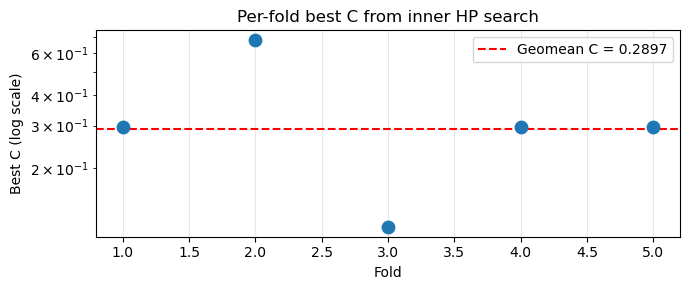

In [15]:
if enable_hp_search:
    _fold_Cs        = [m['fold_C'] for m in cv_fold_metrics]
    _fold_penalties = [m['fold_penalty'] for m in cv_fold_metrics]
    C_VALUE  = float(np.exp(np.mean(np.log(_fold_Cs))))
    PENALTY  = max(set(_fold_penalties), key=_fold_penalties.count)
    print(f'Per-fold C       : {[f"{c:.4g}" for c in _fold_Cs]}')
    print(f'Per-fold penalty : {_fold_penalties}')
    print(f'→ C_VALUE (geometric mean) = {C_VALUE:.4g}')
    print(f'→ PENALTY (mode)           = {PENALTY}')

    # Plot per-fold C values on a log scale
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.scatter(range(1, len(_fold_Cs)+1), _fold_Cs, s=80, zorder=3)
    ax.axhline(C_VALUE, color='red', linestyle='--', label=f'Geomean C = {C_VALUE:.4g}')
    ax.set_yscale('log')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Best C (log scale)')
    ax.set_title('Per-fold best C from inner HP search')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Threshold Tuning

Sweep decision thresholds from 0.20 to 0.76 on OOF probabilities and pick the threshold that maximises macro F1.  

With class imbalance (65% false) and class weights applied, the model's predicted probabilities tend to be biased toward the majority class even after weighting. Lowering the threshold below 0.5 increases recall on class 0 (true statements) at a controlled precision cost, improving macro F1.

Best threshold: 0.46  (OOF macro_f1=0.6038)


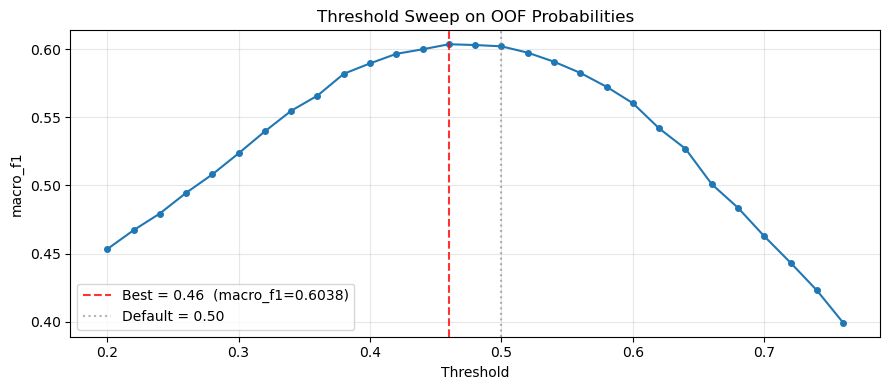

THRESHOLD updated: 0.50 → 0.46


In [16]:
if enable_threshold_tuning:
    _metric_fn = {
        'macro_f1':     lambda t, yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        'mcc':          lambda t, yt, yp: matthews_corrcoef(yt, yp),
        'balanced_acc': lambda t, yt, yp: balanced_accuracy_score(yt, yp),
    }[THRESHOLD_METRIC]

    threshold_grid   = np.arange(0.20, 0.76, 0.02)
    threshold_scores = {}
    for t in threshold_grid:
        preds = (oof_proba >= t).astype(int)
        threshold_scores[round(float(t), 2)] = _metric_fn(t, oof_true, preds)

    best_threshold = max(threshold_scores, key=threshold_scores.get)
    best_score     = threshold_scores[best_threshold]
    print(f'Best threshold: {best_threshold:.2f}  (OOF {THRESHOLD_METRIC}={best_score:.4f})')

    # Threshold sweep plot
    fig, ax = plt.subplots(figsize=(9, 4))
    ts = list(threshold_scores.keys())
    ss = list(threshold_scores.values())
    ax.plot(ts, ss, marker='o', markersize=4, linewidth=1.5)
    ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.8,
               label=f'Best = {best_threshold:.2f}  ({THRESHOLD_METRIC}={best_score:.4f})')
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='Default = 0.50')
    ax.set_xlabel('Threshold')
    ax.set_ylabel(THRESHOLD_METRIC)
    ax.set_title('Threshold Sweep on OOF Probabilities')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if overwrite_threshold:
        print(f'THRESHOLD updated: 0.50 → {best_threshold:.2f}')
        THRESHOLD = best_threshold

## Final Model — Fit on Full Train/Val Set

The final model wraps the base LR in `CalibratedClassifierCV(method='isotonic', cv=5)`.  
Isotonic calibration fits a non-decreasing step function that maps raw probabilities to better-calibrated output, evaluated via 5-fold CV on the training data. This is particularly valuable here because:
1. The class weights shift the raw sigmoid output.
2. Our threshold tuning depends on probabilities being meaningful — miscalibrated probas would make the OOF-tuned threshold unreliable on holdout.

In [17]:
print(f'[{_now()}] Fitting final model...')
_t0 = time()

_final_rate_maps: dict = {}
X_trainval_final = X_trainval.copy()
if enable_true_rate_features and _tr_group_cols:
    for _feat, _src_col in _tr_group_cols.items():
        _rate_map = _grp_trainval.groupby(_src_col)['_label'].mean()
        X_trainval_final[_feat] = _grp_trainval[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        X_holdout[_feat]        = _grp_holdout[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        _final_rate_maps[_feat] = _rate_map.to_dict()

X_fit, y_fit = rebalance_training_data(X_trainval_final, y_trainval, balance_strategy)

_base_lr = LogisticRegression(
    solver='liblinear', C=C_VALUE, penalty=PENALTY,
    class_weight=_lr_class_weight, max_iter=MAX_ITER, random_state=42,
)
model = CalibratedClassifierCV(_base_lr, method='isotonic', cv=5)
model.fit(X_fit, y_fit)
print(f'Done in {time()-_t0:.1f}s  (C={C_VALUE:.4g}, penalty={PENALTY}, calibration=isotonic)')

[20:12:41] Fitting final model...
Done in 2.2s  (C=0.2897, penalty=l2, calibration=isotonic)


## Holdout Evaluation

The holdout set is touched for the first time here. All metrics are at the tuned threshold.  

**Key thing to watch:** Class 0 (true statements) precision and recall — this is the weak spot for LR. If class 0 recall is < 0.50, the model is still biased toward predicting false even after class weighting and threshold tuning.

In [18]:
print(f'Using threshold: {THRESHOLD:.2f}\n')
y_proba = model.predict_proba(X_holdout)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

holdout_metrics = {
    'roc_auc':      roc_auc_score(y_holdout, y_proba),
    'pr_auc':       average_precision_score(y_holdout, y_proba),
    'macro_f1':     f1_score(y_holdout, y_pred, average='macro', zero_division=0),
    'f1_class1':    f1_score(y_holdout, y_pred, zero_division=0),
    'precision':    precision_score(y_holdout, y_pred, zero_division=0),
    'recall':       recall_score(y_holdout, y_pred, zero_division=0),
    'accuracy':     accuracy_score(y_holdout, y_pred),
    'mcc':          matthews_corrcoef(y_holdout, y_pred),
    'balanced_acc': balanced_accuracy_score(y_holdout, y_pred),
}
cm     = confusion_matrix(y_holdout, y_pred)

display(pd.DataFrame.from_dict(holdout_metrics, orient='index', columns=['value']).round(4))
print()
print(classification_report(y_holdout, y_pred, target_names=['True (0)', 'False (1)']))

Using threshold: 0.46



,value
roc_auc,0.6603
pr_auc,0.7709
macro_f1,0.5548
f1_class1,0.7744
precision,0.6836
recall,0.8930
accuracy,0.6631
mcc,0.1771
balanced_acc,0.5669



              precision    recall  f1-score   support

    True (0)       0.55      0.24      0.34       631
   False (1)       0.68      0.89      0.77      1159

    accuracy                           0.66      1790
   macro avg       0.62      0.57      0.55      1790
weighted avg       0.64      0.66      0.62      1790



## Coefficient Inspection

LR's interpretability advantage over trees: the coefficients directly show which features push predictions toward false (positive weight) or toward true (negative weight).

Because `CalibratedClassifierCV` wraps 5 internal estimators, we average their coefficients.  
Embedding dimensions (`vec_*`) will dominate by count, but non-embedding features may have larger individual weights.

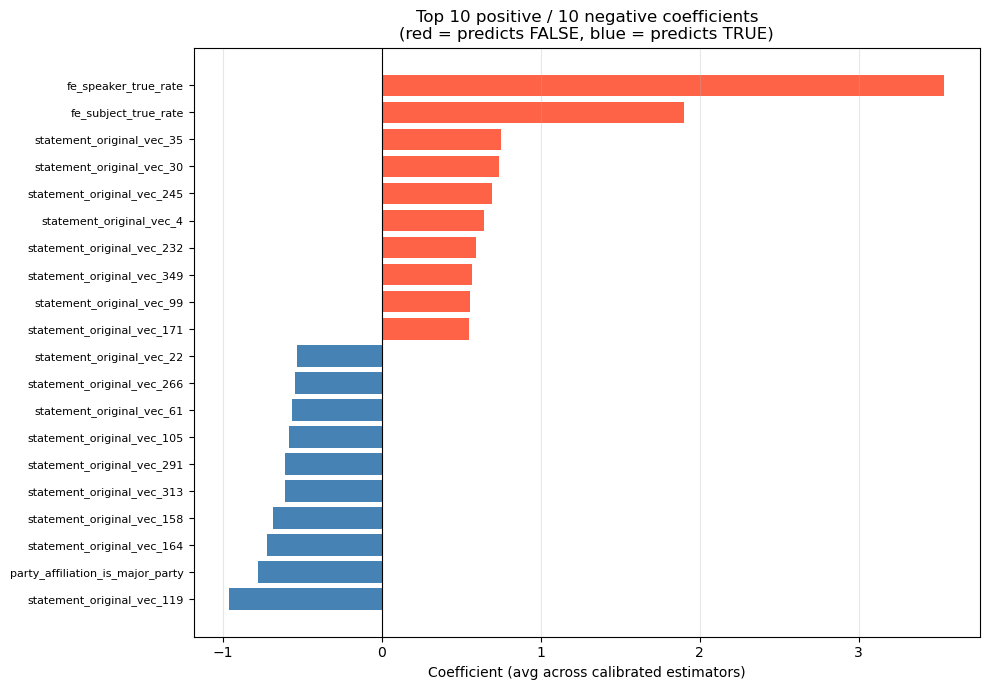


Top 10 by absolute weight:


,feature,coefficient
0,fe_speaker_true_rate,3.5373
1,fe_subject_true_rate,1.9020
2,statement_original_vec_119,-0.9605
3,party_affiliation_is_major_party,-0.7830
4,statement_original_vec_35,0.7512
5,statement_original_vec_30,0.7338
6,statement_original_vec_164,-0.7240
7,statement_original_vec_245,0.6932
8,statement_original_vec_158,-0.6872
9,statement_original_vec_4,0.6429


In [19]:
# Average coefficients from the 5 calibrated estimators
feature_names = X_trainval_final.columns.tolist()
_coefs = np.mean(
    [est.estimator.coef_[0] for est in model.calibrated_classifiers_],
    axis=0
)
coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': _coefs})
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)

TOP_N = 20
top_pos = coef_df[coef_df['coefficient'] > 0].head(TOP_N // 2)
top_neg = coef_df[coef_df['coefficient'] < 0].head(TOP_N // 2)
top_coefs = pd.concat([top_pos, top_neg]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in top_coefs['coefficient']]
ax.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {TOP_N // 2} positive / {TOP_N // 2} negative coefficients\n'
             f'(red = predicts FALSE, blue = predicts TRUE)')
ax.set_xlabel('Coefficient (avg across calibrated estimators)')
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 10 by absolute weight:')
display(coef_df[['feature', 'coefficient']].head(10).round(4))

## Evaluation Plots

- **ROC curve**: ranking ability across all thresholds — area = 0.5 is random, 1.0 is perfect.
- **Precision-Recall curve**: better than ROC for imbalanced datasets. A naive classifier that predicts all-false would have recall=0 for class 1 — PR-AUC penalises this.
- **Confusion matrix**: per-cell counts at the tuned threshold.  <br>
TN (true statements correctly identified) vs FN (true statements predicted as false).

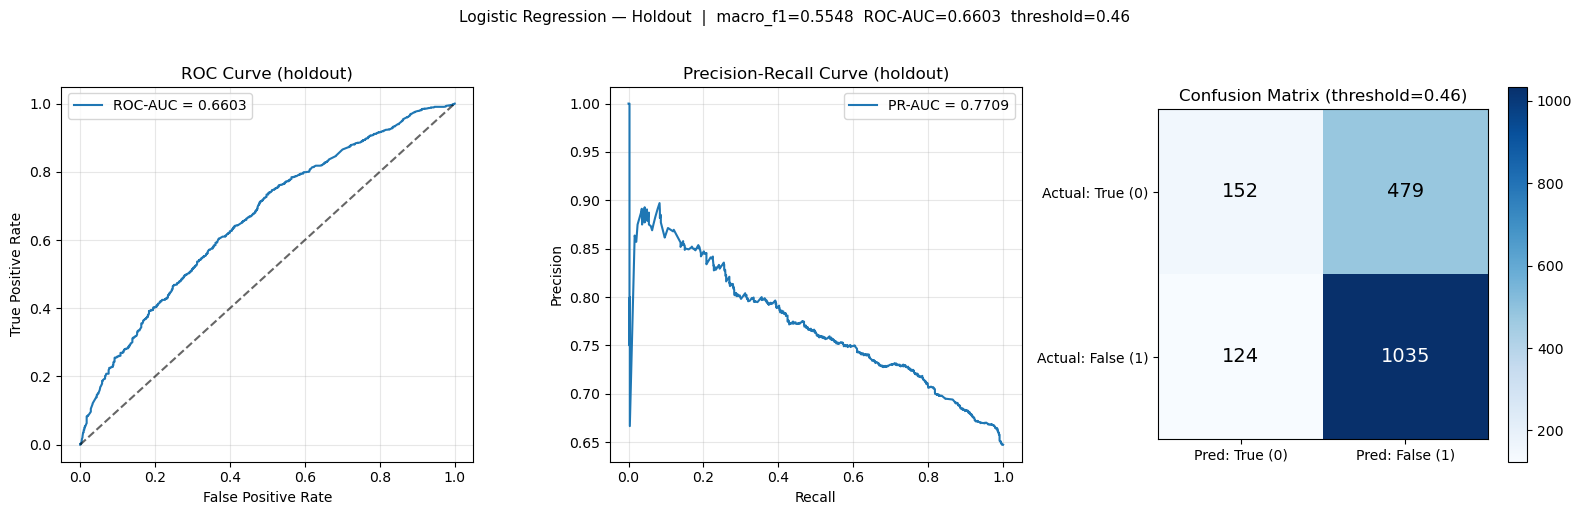

In [20]:
fpr, tpr, _      = roc_curve(y_holdout, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_holdout, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {holdout_metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('ROC Curve (holdout)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(rec_c, prec_c, label=f"PR-AUC = {holdout_metrics['pr_auc']:.4f}")
axes[1].set_title('Precision-Recall Curve (holdout)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].set_title(f'Confusion Matrix (threshold={THRESHOLD:.2f})')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred: True (0)', 'Pred: False (1)'])
axes[2].set_yticklabels(['Actual: True (0)', 'Actual: False (1)'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
fig.colorbar(im, ax=axes[2])

plt.suptitle(
    f'Logistic Regression — Holdout  |  macro_f1={holdout_metrics["macro_f1"]:.4f}  '
    f'ROC-AUC={holdout_metrics["roc_auc"]:.4f}  threshold={THRESHOLD:.2f}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## Summary

**Logistic Regression results** (baseline for the project):

| Metric | Expected range | Notes |
|---|---|---|
| Macro F1 | 0.60–0.64 | Driven down by class 0 (true statements) |
| ROC-AUC | 0.65–0.72 | Ranking ability is decent for a linear model |
| Class 0 recall | 0.50–0.65 | Key weakness — model is biased toward predicting false |

**LR baseline for the following training:**
- **Random Forest**: tests whether non-linear splits on the same features improve class 0 recall.
- **LightGBM / CatBoost**: gradient boosting handles mixed feature types better and can learn interaction effects that LR can't.
- **Stacking**: combines OOF predictions from multiple models — the linear + tree combination often adds 1–2 F1 points.
- **Transformers**: fine-tuning DeBERTa or a 7B LoRA model on the raw text breaks through the embedding ceiling entirely.